In [62]:
# Install Kaggle and Kagglehub libraries
!pip install kaggle kagglehub

In [63]:
!pip install tensorflow

In [64]:

import kagglehub
import os,itertools
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import files

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
# Upload your kaggle.json file
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle kimlik bilgileri başarıyla ayarlandı.")

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 67 bytes
Kaggle kimlik bilgileri başarıyla ayarlandı.


In [67]:
# Download dataset using Kagglehub
KAGGLE_DATASET_REF = 'berkaykocaoglu/tr-sign-language'
dataset_path = kagglehub.dataset_download(KAGGLE_DATASET_REF)
print(f"{KAGGLE_DATASET_REF} veri seti indirildi ve buraya açıldı: {dataset_path}")

Using Colab cache for faster access to the 'tr-sign-language' dataset.
berkaykocaoglu/tr-sign-language veri seti indirildi ve buraya açıldı: /kaggle/input/tr-sign-language


In [68]:
# Check dataset folder contents
!ls /root/.cache/kagglehub/datasets/berkaykocaoglu/tr-sign-language/versions/1

 tr_signLanguage_dataset  'tr sign language.png'


In [69]:
# Set dataset path and train/test directories
dataset_path = "/root/.cache/kagglehub/datasets/berkaykocaoglu/tr-sign-language/versions/1/tr_signLanguage_dataset"
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")


In [70]:
#Parameters
batch_size=32
image_size=(64,64)
seed=42
AUTOTUNE = tf.data.AUTOTUNE

In [71]:
# Create train, validation and test datasets
train_ds=tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    batch_size=batch_size,
    image_size=image_size,
    validation_split=0.20,
    subset="training",
    shuffle=True,
    seed=seed,
)

val_ds=tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    batch_size=batch_size,
    image_size=image_size,
    validation_split=0.20,
    subset="validation",
    shuffle=True,
    seed=seed,
)

test_ds=tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    batch_size=batch_size,
    image_size=image_size,
    shuffle=False,
)

Found 119400 files belonging to 26 classes.
Using 95520 files for training.
Found 119400 files belonging to 26 classes.
Using 23880 files for validation.
Found 47796 files belonging to 26 classes.


In [72]:
# Class names
print("Train classes:", train_ds.class_names)
print("Validation classes:", val_ds.class_names)
print("Test classes:", test_ds.class_names)

# Class Count
print("Train Classes Count:",len(train_ds.class_names))
print("Validation Classes Count:",len(val_ds.class_names))
print("Test Classes Count:",len(test_ds.class_names))

Train classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z', 'del', 'nothing', 'space']
Validation classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z', 'del', 'nothing', 'space']
Test classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z', 'del', 'nothing', 'space']
Train Classes Count: 26
Validation Classes Count: 26
Test Classes Count: 26


In [73]:
# Check input shape
for images, labels in train_ds.take(1):
    print("Batch shape:", images.shape)
    input_shape = images.shape[1:]
    print(input_shape)

Batch shape: (32, 64, 64, 3)
(64, 64, 3)


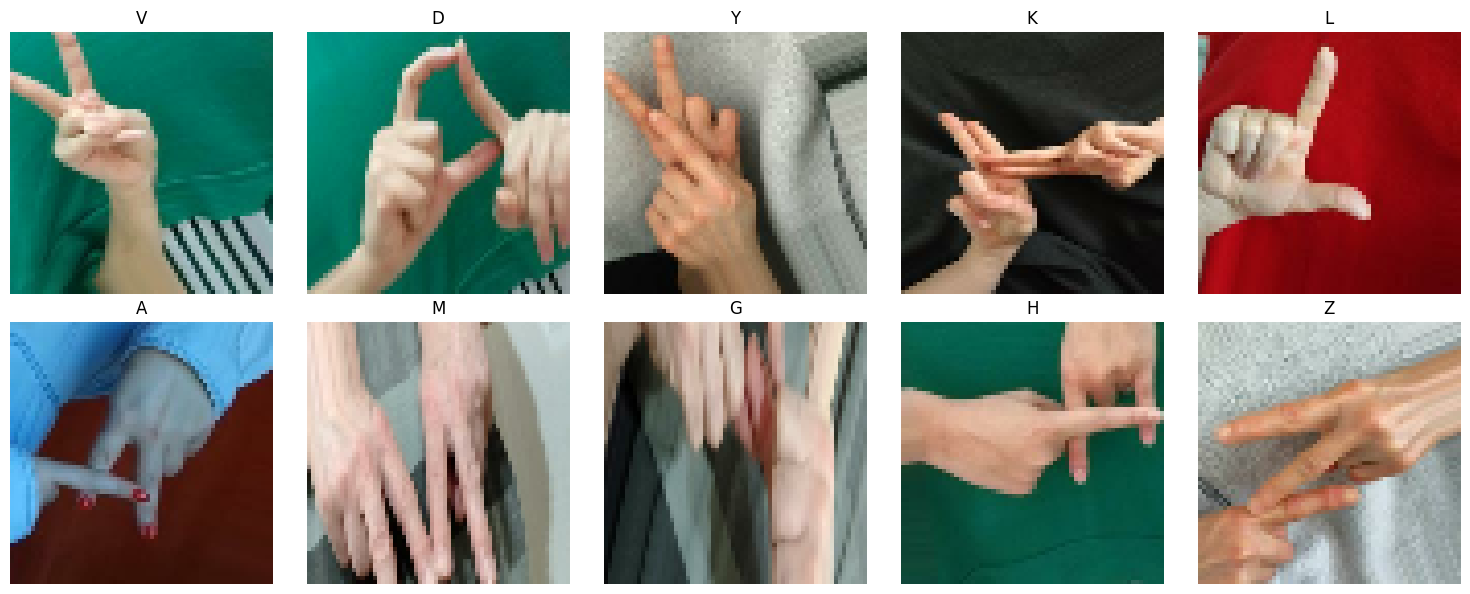

In [74]:
# Visualize sample images with labels
def visualize_img(image_batch, label_batch, class_names):

    plt.figure(figsize=(15, 6))

    for n in range(10):
        ax = plt.subplot(2, 5, n + 1)

        img = np.array(image_batch[n]).squeeze()

        if img.max() > 1.0:
            img = img / 255.0
        if len(img.shape) == 3:
            plt.imshow(img)
        else:
            plt.imshow(img, cmap='gray')
        index = np.argmax(label_batch[n])
        plt.title(class_names[index])

        plt.axis("off")

    plt.tight_layout()
    plt.show()

for image_batch, label_batch in train_ds.take(1):
    visualize_img(image_batch, label_batch, train_ds.class_names)

In [75]:
# Data Augmentation
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.1,width_factor=0.1)
])

In [76]:
# Normalization layer
normalization_layer=tf.keras.layers.Rescaling(1./255)

In [77]:
# Apply augmentation and prefetch
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch (AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [78]:
# Build CNN model
model = models.Sequential([
    layers.Input(shape=input_shape),


    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),


    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(units=26,activation="softmax")
])

In [79]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │        13,338 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,501,338 (9.54 MB)

 Trainable params: 2,500,378 (9.54 MB)

 Non-trainable params: 960 (3.75 KB)

In [80]:
# Compile model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=[tf.keras.metrics.Precision(),tf.keras.metrics.Recall(),"acc"]
)

In [81]:
# Setup callbacks
callbacks=[EarlyStopping(monitor="val_loss", patience=50,verbose=1,mode="min"),
           ModelCheckpoint(filepath="/content/drive/MyDrive/sign_languange_model.keras",monitor="val_loss",mode="min",save_best_only=True,save_weights_only=False)]


In [82]:
# Train the model
history = model.fit(
train_ds,
validation_data=val_ds,
epochs=30,
callbacks=callbacks
)

Epoch 1/30
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 179s 57ms/step - acc: 0.0894 - loss: 3.0240 - precision: 0.5162 - recall: 0.0229 - val_acc: 0.1119 - val_loss: 2.8720 - val_precision: 0.6576 - val_recall: 0.0334
Epoch 2/30
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 178s 51ms/step - acc: 0.1188 - loss: 2.8381 - precision: 0.6517 - recall: 0.0450 - val_acc: 0.1547 - val_loss: 2.6359 - val_precision: 0.8674 - val_recall: 0.0268
Epoch 3/30
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 154s 52ms/step - acc: 0.1618 - loss: 2.6089 - precision: 0.6648 - recall: 0.0620 - val_acc: 0.2556 - val_loss: 2.2994 - val_precision: 0.6970 - val_recall: 0.0741
Epoch 4/30
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 157s 53ms/step - acc: 0.2890 - loss: 2.1412 - precision: 0.7058 - recall: 0.1426 - val_acc: 0.3986 - val_loss: 1.9644 - val_precision: 0.6447 - val_recall: 0.2474
Epoch 5/30
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 154s 52ms/step - acc: 0.4640 - loss: 1.5877 - precision: 0.7523 - recall: 0.3127 - val_acc: 0.5210 - val_loss: 1.4014 - val_precision: 0.6

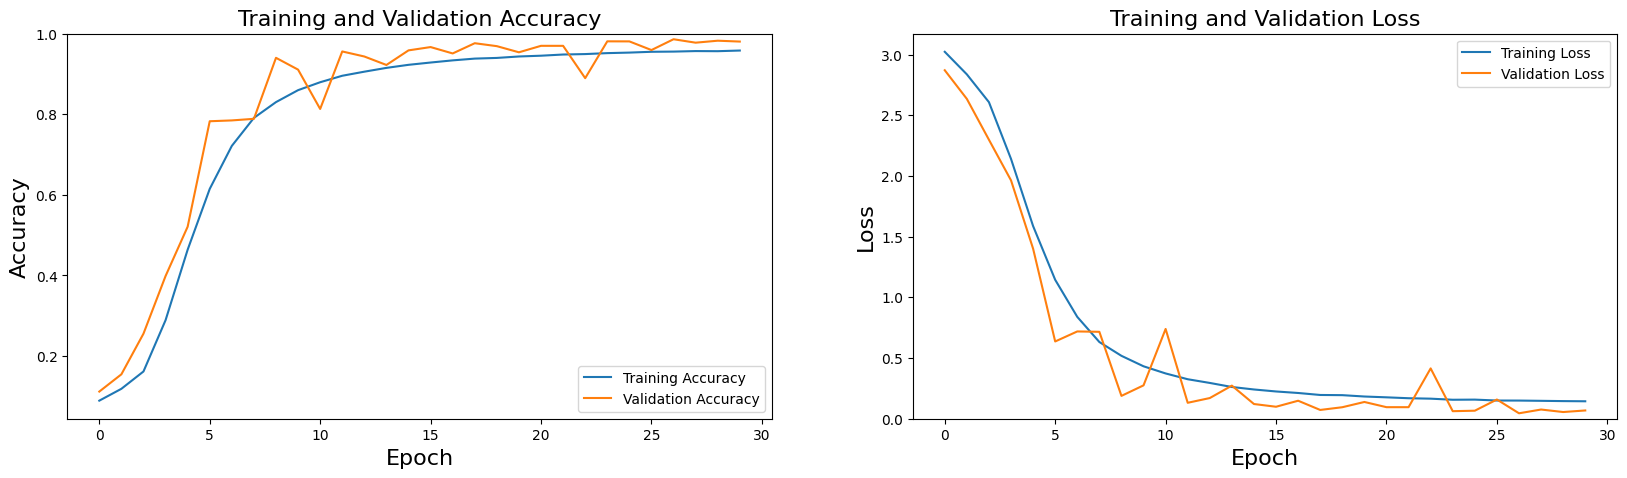

In [83]:
#--------------------
# Accuracy
#--------------------

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['acc' ], label='Training Accuracy')
plt.plot(history.history['val_acc' ], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy', fontsize=16)

#--------------------
# Loss
#--------------------

plt.subplot(1, 2, 2)
plt.plot(history.history['loss' ], label='Training Loss')
plt.plot(history.history['val_loss' ], label='Validation Loss')
plt.legend(loc='upper right')
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.ylim([0,max(plt.ylim()) ])
plt.title('Training and Validation Loss', fontsize=16)
plt.show()

In [85]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/sign_languange_model.keras")

In [86]:
y_pred = model.predict(test_ds)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x, y in test_ds])
y_true = np.argmax(y_true, axis=1)

1494/1494 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step


In [87]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1962
           1       1.00      1.00      1.00      1929
           2       0.99      1.00      0.99      1953
           3       0.96      0.98      0.97      1948
           4       1.00      0.99      0.99      1943
           5       1.00      0.98      0.99      1973
           6       1.00      0.95      0.97      1947
           7       1.00      0.99      1.00      1952
           8       0.98      1.00      0.99      1933
           9       0.98      0.98      0.98      1944
          10       0.99      1.00      0.99      1950
          11       0.99      0.98      0.99      1958
          12       0.92      0.99      0.95      1934
          13       0.98      0.94      0.96      1941
          14       0.99      1.00      1.00      1945
          15       0.99      0.99      0.99      1953
          16       0.99      0.99      0.99      1936
          17       0.99    

In [88]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
#This function prints and plotst the confusion matrix.
#Normalization can be applied by setting normalize=True'.
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label', fontweight="bold")
    plt.xlabel('Predicted label', fontweight="bold")

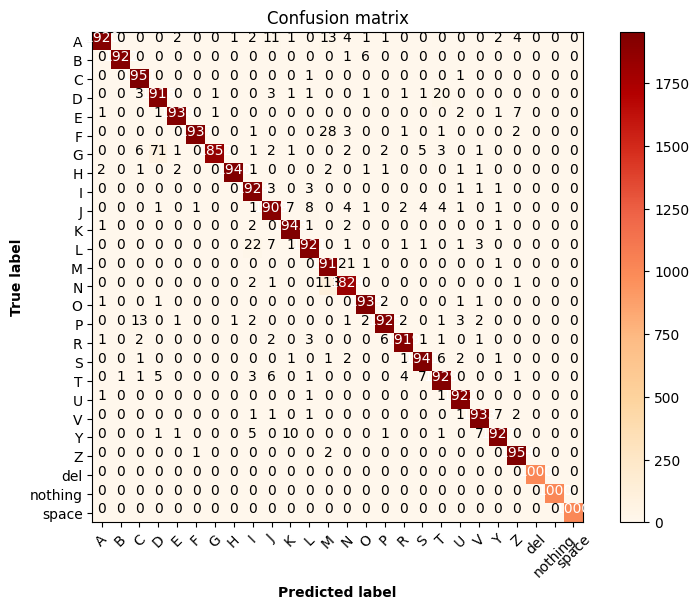

In [89]:
labels = sorted(os.listdir(train_dir))

plot_confusion_matrix(cm, labels,
                      title='Confusion matrix',
                      cmap=plt.cm.OrRd)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


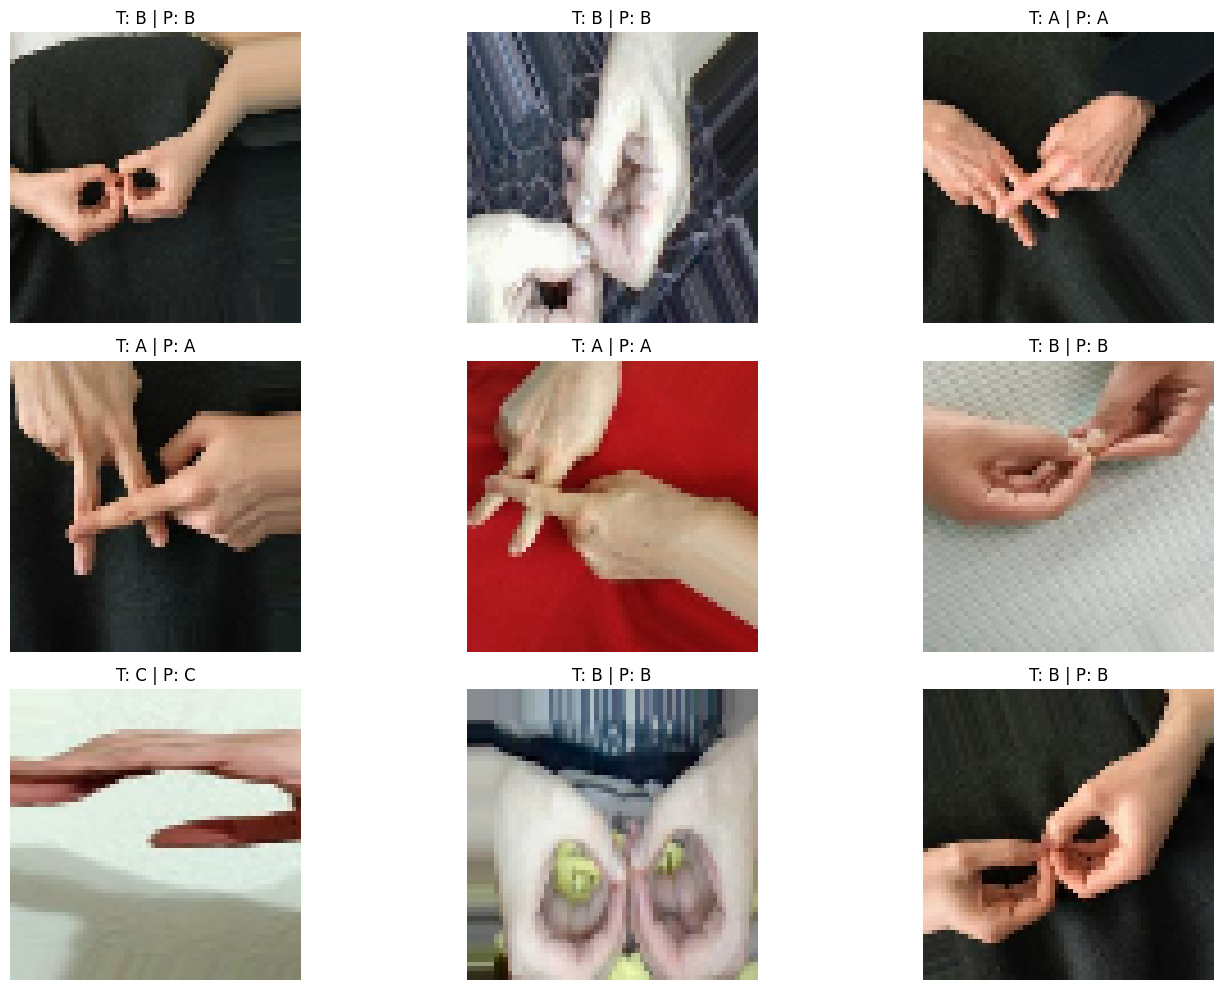

In [97]:
#Comparison of model predictions with test data

classes = sorted(os.listdir(test_dir))
plt.figure(figsize=(15, 10))

random_test_sample = test_ds.unbatch().shuffle(buffer_size=5000).batch(9).take(1)

for images, labels in random_test_sample:
    predictions = model.predict(images)
    predictions = np.argmax(predictions, axis=1)

    if len(labels.shape) > 1:
        labels = np.argmax(labels, axis=1)
    else:
        labels = labels.numpy()

    for i in range(len(images)):
        plt.subplot(3, 3, i + 1)

        img = images[i].numpy().astype("uint8")
        plt.imshow(img)

        true_label = classes[int(labels[i])]
        pred_label = classes[int(predictions[i])]

        plt.title(f"T: {true_label} | P: {pred_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()